# 01 - Elo ratings, 1993-2018

Build a running Elo rating for every Bundesliga club across 25 seasons, then read the league's history off the ratings: who was dominant, who collapsed, and which single seasons were the strongest.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join('..', 'src')))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from elo_ratings import data
from elo_ratings.elo import Elo
df = data.load_results()
elo = Elo().run(df)
hist = elo.history_frame()
len(df)

7650

## The 25-year picture

Season-average rating for six clubs whose stories the ratings capture. Lines break where a club was relegated out of the division.

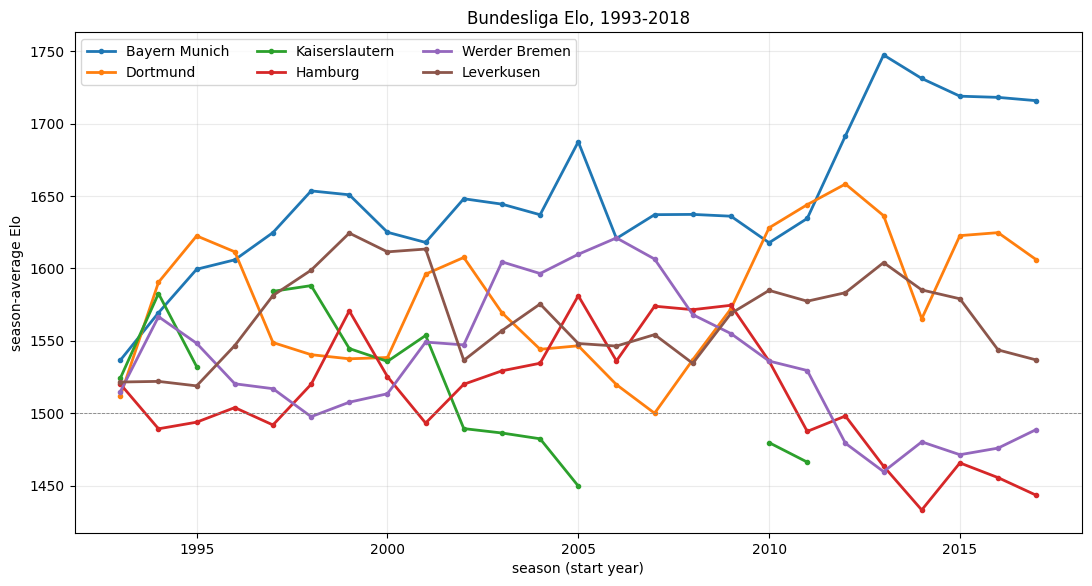

In [2]:
hist['SeasonStart'] = hist['Season'].str.slice(0,4).astype(int)
seasons = sorted(hist.SeasonStart.unique())
season_avg = hist.groupby(['Team','SeasonStart']).Rating.mean().unstack('Team').reindex(seasons)
teams = ['Bayern Munich','Dortmund','Kaiserslautern','Hamburg','Werder Bremen','Leverkusen']
fig, ax = plt.subplots(figsize=(13,6.5))
for t in teams:
    ax.plot(season_avg.index, season_avg[t], marker='o', ms=3, lw=2, label=t)
ax.axhline(1500, color='grey', lw=.6, ls='--')
ax.set_xlabel('season (start year)'); ax.set_ylabel('season-average Elo')
ax.set_title('Bundesliga Elo, 1993-2018'); ax.legend(ncol=3); ax.grid(alpha=.25)
plt.show()

## Most dominant single seasons

Bayern's 2012-2018 run shows up as the six strongest team-seasons in the whole dataset.

In [3]:
savg = hist.groupby(['Team','Season']).Rating.mean().sort_values(ascending=False)
savg.head(8).round(0)

Team           Season 
Bayern Munich  2013-14    1747.0
               2014-15    1731.0
               2015-16    1719.0
               2016-17    1718.0
               2017-18    1716.0
               2012-13    1692.0
               2005-06    1687.0
Dortmund       2012-13    1658.0
Name: Rating, dtype: float64

## Highest peaks ever reached

In [4]:
peak = hist.loc[hist.groupby('Team').Rating.idxmax()].sort_values('Rating', ascending=False)
peak[['Team','Season','Date','Rating']].head(8).assign(Rating=lambda d: d.Rating.round(0)).to_string(index=False)

"         Team  Season       Date  Rating\nBayern Munich 2013-14 2014-03-25  1796.0\n     Dortmund 2011-12 2012-05-05  1712.0\n   Leverkusen 1999-00 2000-05-13  1677.0\nWerder Bremen 2003-04 2004-05-08  1661.0\n   Schalke 04 2006-07 2007-02-10  1651.0\n    Wolfsburg 2014-15 2015-04-11  1640.0\n   M'gladbach 2014-15 2015-05-16  1639.0\n    Stuttgart 2006-07 2007-05-19  1627.0"